<img src="https://devra.ai/analyst/notebook/3650/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;"><div style="font-size:150%; color:#FEE100"><b>Exam Score Prediction and Analysis Notebook</b></div><div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

Welcome curious reader. This notebook sets out to explore a dataset about exam scores with a variety of features. Our journey will take us from a deep exploratory data analysis to building a predictive model for exam scores. If you find the notebook useful, feel free to upvote it.

## Table of Contents

- [Imports and Setup](#Imports-and-Setup)
- [Data Loading](#Data-Loading)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Visualization](#Visualization)
- [Predictive Modeling](#Predictive-Modeling)
- [Conclusions and Future Work](#Conclusions-and-Future-Work)

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Ensure matplotlib uses a non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If only plt is imported
%matplotlib inline
import seaborn as sns

# Scikit-learn imports for predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print('Imports and setup complete.')

Imports and setup complete.


In [2]:
# Data Loading
file_path = '/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv'

try:
    df = pd.read_csv(file_path, encoding='ascii', delimiter=',')
    print('Data loaded successfully.')
except FileNotFoundError as e:
    print('File not found. Please ensure the dataset is in the correct location.')
    raise e

# Display the first few rows of the dataset
df.head()

Data loaded successfully.


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,200.99,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,200.99,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,200.99,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,200.99,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


## Exploratory Data Analysis

Before getting into the nitty gritty, it is interesting to note that the dataset contains various factors that might influence a student's exam score. These range from the student's study habits to their sleep quality. Our goal here is to establish a foundational understanding of the dataset through summary statistics and visualizations.

In [3]:
# Exploratory Data Analysis (EDA)
print('Dataset dimensions:', df.shape)
print('\nData Types:')
print(df.dtypes)

# Summary statistics for numeric columns
print('\nSummary Statistics:')
print(df.describe())

# Check for missing values
print('\nMissing Values:')
print(df.isnull().sum())

Dataset dimensions: (20000, 13)

Data Types:
student_id          float64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object

Summary Statistics:
         student_id           age   study_hours  class_attendance  \
count  20000.000000  20000.000000  20000.000000      20000.000000   
mean   10000.500000     20.473300      4.007603         70.017365   
std     5770.211372      2.284458      2.308313         17.282262   
min      200.990000     17.000000      0.080000         40.600000   
25%     5000.750000     18.000000      2.000000         55.100000   
50%    10000.500000     20.000000      4.040000         69.900000   
75%    15000.250000     22.000000      6.000000         85.000000   
max 

## Data Cleaning and Preprocessing

The dataset appears to be in good shape; however, common issues include missing values, type mismatches, or issues with categorical variables. In this section we perform minimal cleaning and ensure that our categorical variables are correctly encoded for further analysis and modeling.

Note: Even if no errors occur during future runs, it is helpful to include cleaning techniques that others might find useful.

In [4]:
# Data Cleaning and Preprocessing
# Convert any columns to the appropriate type if necessary
categorical_columns = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype('category')

# In this dataset, there are no explicit date columns. If there were any, we would use pd.to_datetime to convert them.

# Check for any missing values and handle if necessary
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print('Missing values detected and dropped.')
else:
    print('No missing values detected.')

# Display updated dataframe information
df.info()

No missing values detected.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   student_id        20000 non-null  float64 
 1   age               20000 non-null  int64   
 2   gender            20000 non-null  category
 3   course            20000 non-null  category
 4   study_hours       20000 non-null  float64 
 5   class_attendance  20000 non-null  float64 
 6   internet_access   20000 non-null  category
 7   sleep_hours       20000 non-null  float64 
 8   sleep_quality     20000 non-null  category
 9   study_method      20000 non-null  category
 10  facility_rating   20000 non-null  category
 11  exam_difficulty   20000 non-null  category
 12  exam_score        20000 non-null  float64 
dtypes: category(7), float64(5), int64(1)
memory usage: 1.1 MB


## Visualization

Visualizations provide an engaging way to understand our data. We will use a mix of histograms, count plots, pair plots, and a correlation heatmap. The variety of visualizations should unearth interesting relationships between features and the eventual exam score.

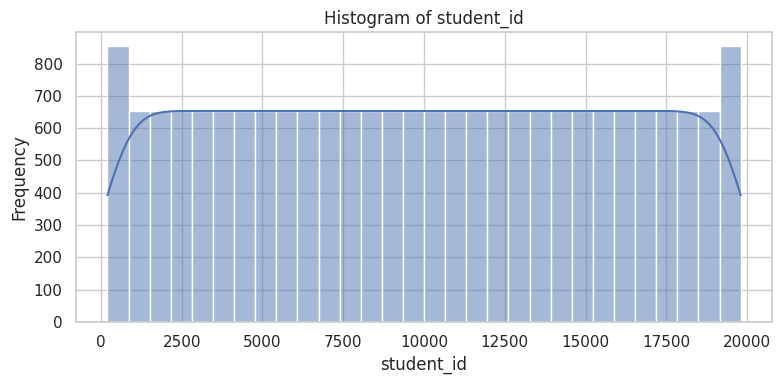

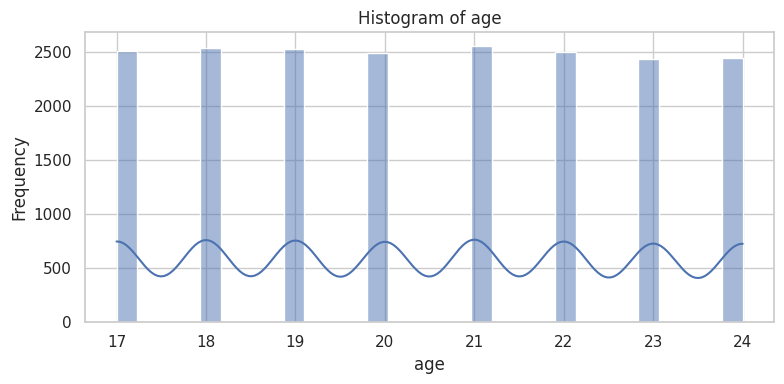

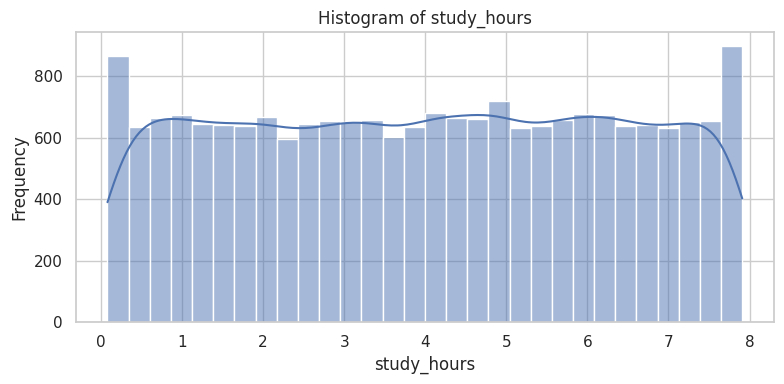

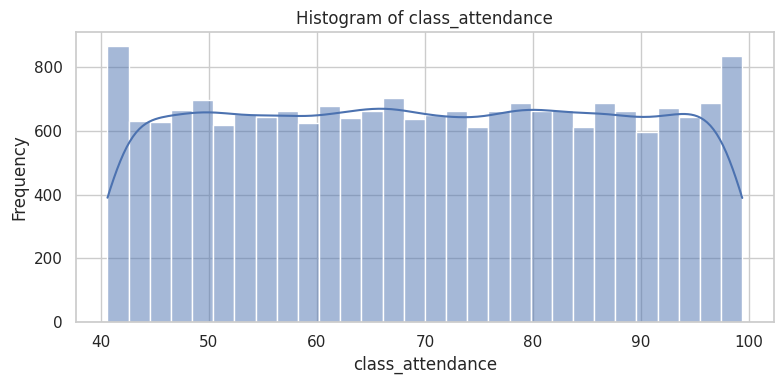

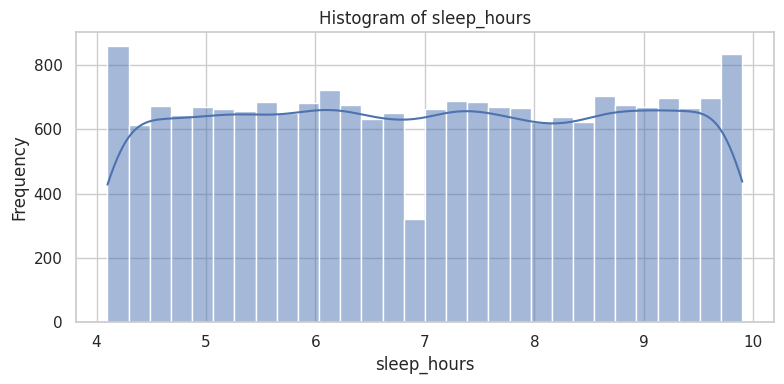

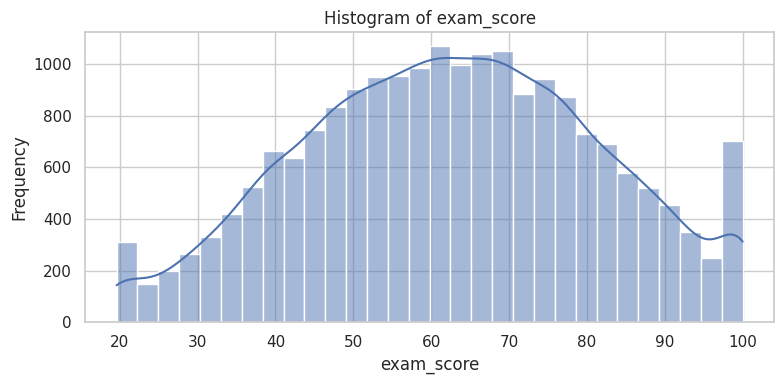

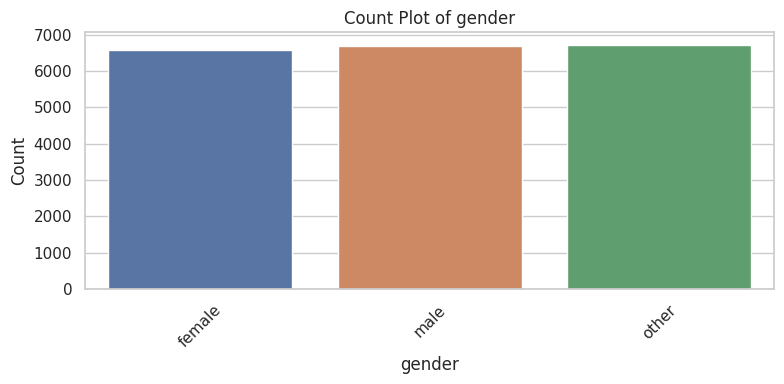

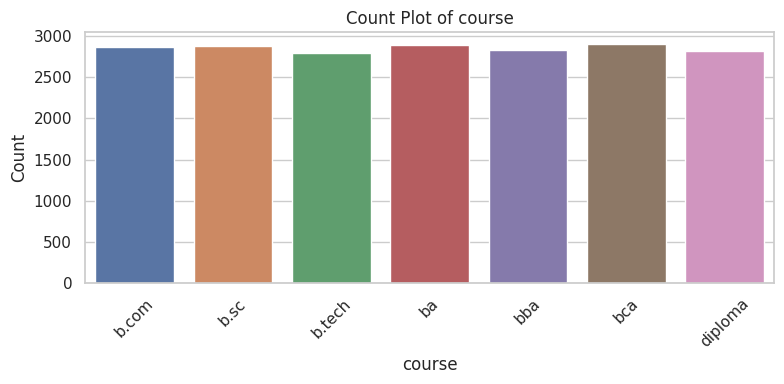

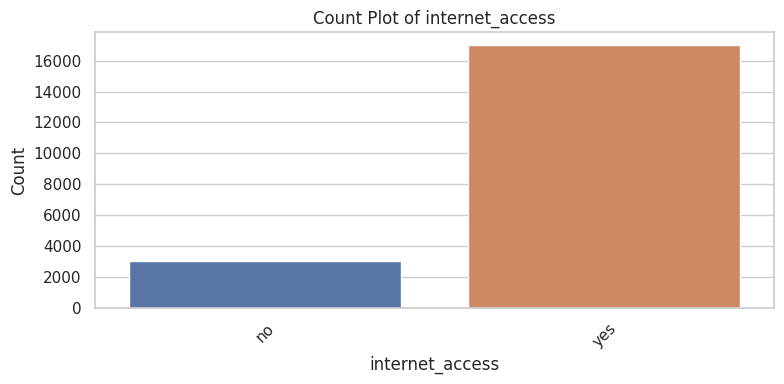

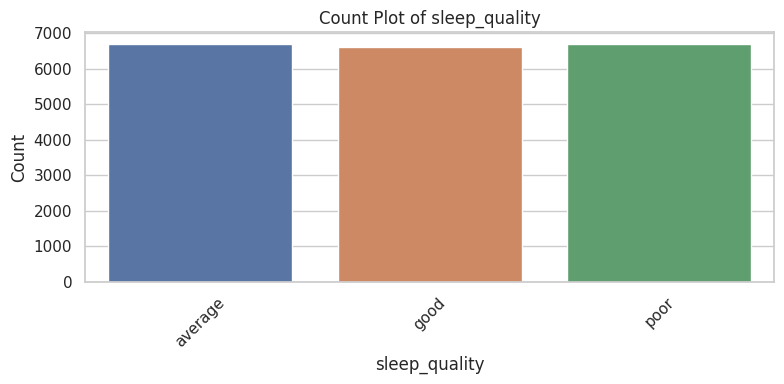

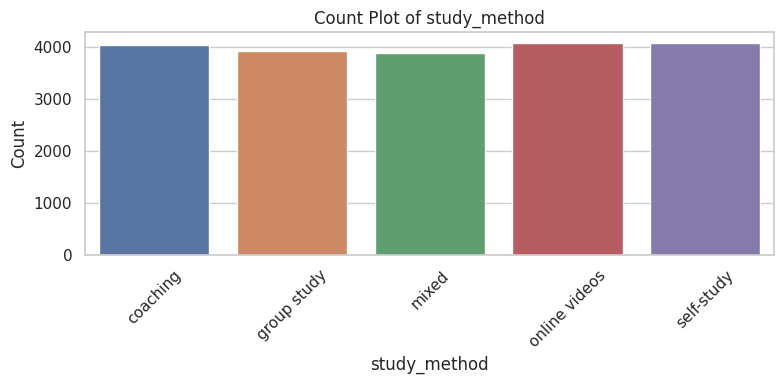

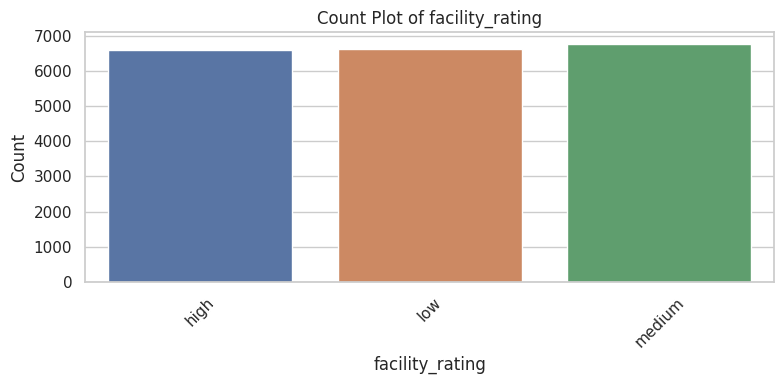

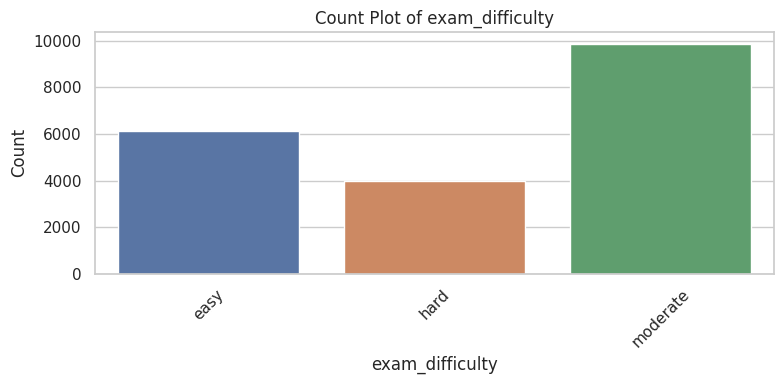

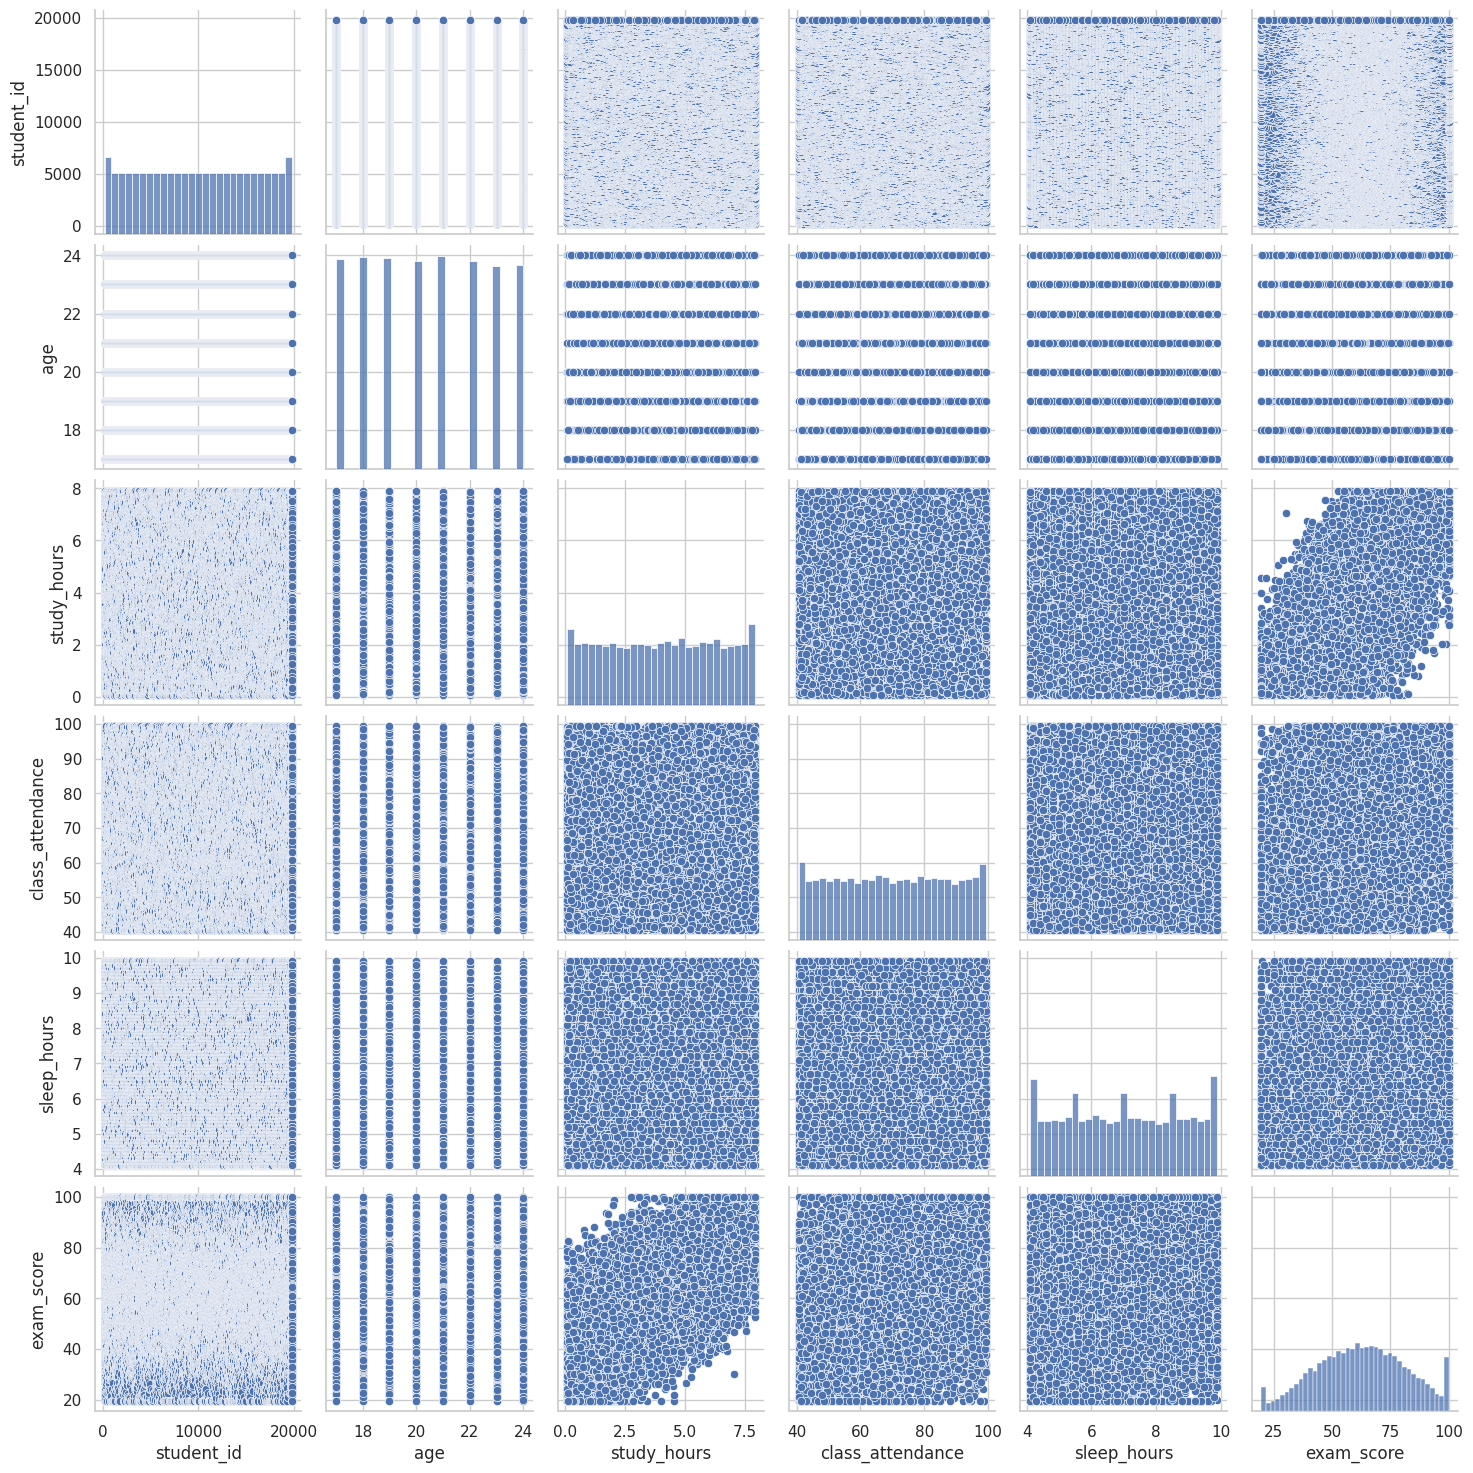

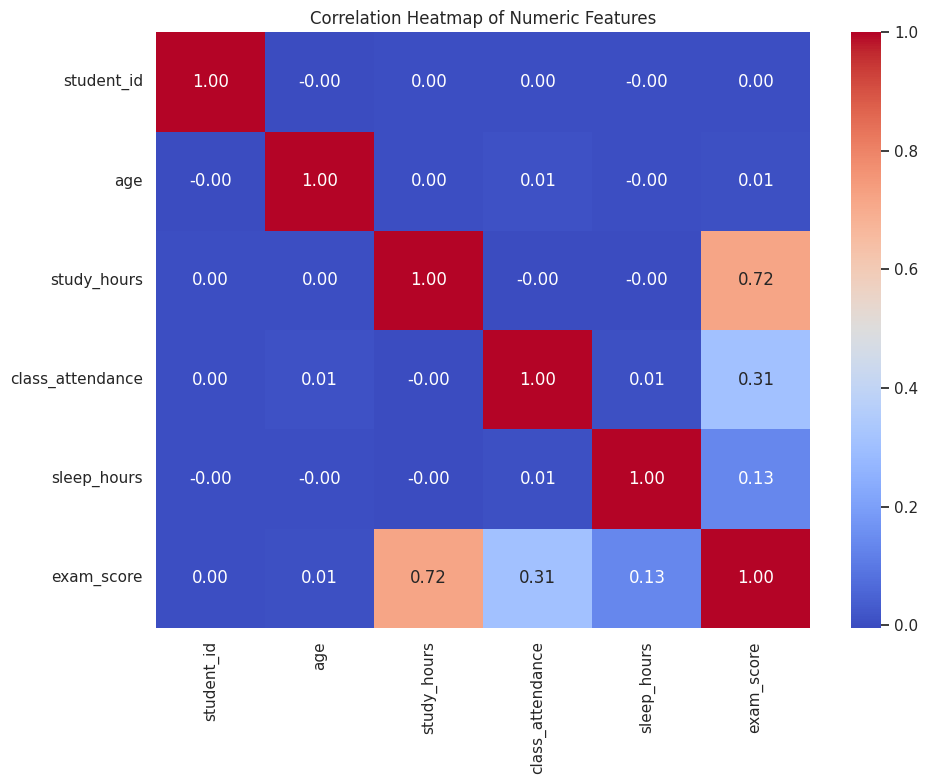

In [5]:
# Visualization
sns.set(style='whitegrid')

## Histograms for numeric variables
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## Count plots (Pie chart alternative) for categorical variables
for col in categorical_columns:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, data=df)
        plt.title(f'Count Plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## Pair Plot for numeric variables if there are at least 4 numeric columns
if len(numeric_columns) >= 4:
    sns.pairplot(df[numeric_columns])
    plt.show()

## Correlation Heatmap for numeric variables
if len(numeric_columns) >= 4:
    plt.figure(figsize=(10, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

## Predictive Modeling

Now that we have a good sense of our data, it seems apt to build a simple prediction model. We will try to predict the exam score using the other features. Given the data is largely a mix of numeric and categorical variables, we will preprocess the data accordingly and use a basic linear regression model. The performance of the model will be evaluated using the R² score and Mean Squared Error. Not only does this model provide baseline predictions, but it can also offer insights into which features are important for exam performance.

Training set shape: (16000, 23)
Test set shape: (4000, 23)
Mean Squared Error: 95.50
R^2 Score: 0.73


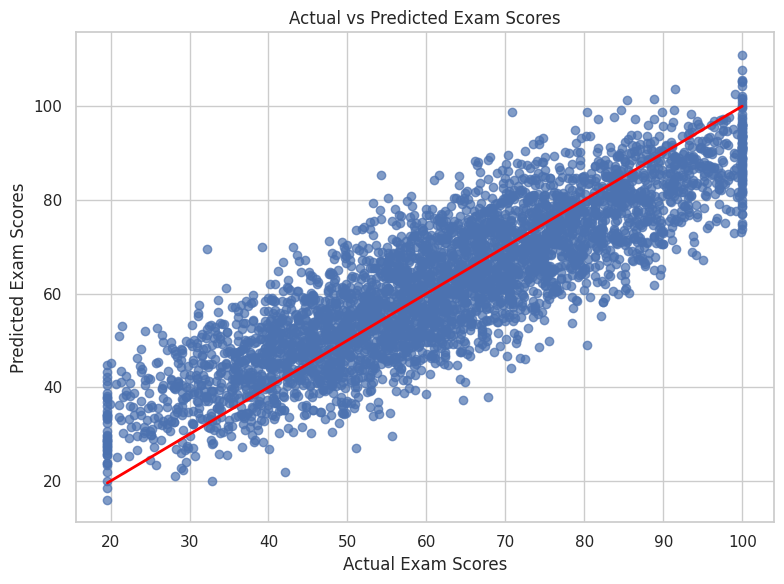

In [6]:
# Prepare data for the predictive model

# Drop student_id as it is not informative for prediction
df_model = df.drop(columns=['student_id'])

# Identify target and feature variables
target = 'exam_score'
features = df_model.drop(columns=[target]).columns

# Convert categorical features to dummy variables
df_model_encoded = pd.get_dummies(df_model, drop_first=True)

# Split data into training and testing sets
X = df_model_encoded.drop(columns=[target])
y = df_model_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R^2 Score: {r2:.2f}')

# Optional: Visual inspection of predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Actual vs Predicted Exam Scores')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.tight_layout()
plt.show()

## Conclusions and Future Work

This notebook provided an in-depth analysis of a dataset that explores various factors influencing exam scores. We began with loading and investigating the data, followed by several visualizations to understand distribution and correlations. A baseline linear regression model was then built to predict exam score, yielding an initial evaluation using the R² score and Mean Squared Error.

The current approach allows a glimpse into predictive performance; however, future analysis might involve:

- Refining the feature engineering process by incorporating domain-specific transformations.
- Experimenting with more sophisticated models such as Random Forests or Gradient Boosting Machines to potentially improve prediction accuracy.
- Analyzing residuals for any non-linear patterns that may call for advanced regression techniques.
- Applying techniques like permutation importance to further interpret feature contributions.

Thank you for following this analysis. If you found the notebook useful, please consider upvoting it.